<a href="https://colab.research.google.com/github/2403a54124-ux/NLP-NATURAL-LANGUAGE-PROCESS-/blob/main/Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

data = {
"review":[
"Movie was amazing and very interesting",
"I hated this movie it was boring",
"Fantastic acting and great story",
"Worst movie ever made",
"Really enjoyed the film",
"Terrible direction and bad acting",
"The storyline was very engaging",
"This film was a complete waste of time",
"A wonderful cinematic experience",
"I dislike this movie so much",
"Great acting by the lead actor",
"The plot was dull and predictable",
"I loved the music in the movie",
"Very disappointing film",
"The movie had excellent visuals",
"Awful screenplay and poor acting",
"A brilliant masterpiece",
"I regret watching this film",
"The characters were well developed",
"The movie was extremely boring",
"Superb direction and editing",
"Bad storyline and weak script",
"An outstanding performance by the cast",
"I will never watch this movie again",
"The movie kept me entertained",
"It was a horrible experience",
"A fantastic movie with great emotions",
"The acting was terrible",
"A very inspiring story",
"The film lacked creativity",
"Absolutely loved the movie",
"The movie was poorly executed",
"One of the best movies I have seen",
"The film was not interesting",
"A heartwarming story",
"I did not like the movie",
"Beautiful cinematography",
"The acting ruined the film",
"The plot twists were amazing",
"The movie was very slow",
"Highly recommended film",
"I found the movie annoying",
"Wonderful storytelling",
"The movie was badly directed",
"The film made me very happy",
"Not worth watching",
"A powerful and emotional movie",
"The script was weak",
"The performances were outstanding",
"The movie felt very long and boring",
"A great movie to watch with family",
"The movie disappointed me",
"A creative and fresh storyline",
"I hated every minute of the film",
"Excellent background music",
"The film was very dull",
"A movie full of excitement",
"Very poor acting",
"I enjoyed the whole movie",
"It was not entertaining",
"A fantastic journey from start to end",
"The story made no sense",
"An unforgettable movie experience",
"The movie was extremely bad",
"Very touching and emotional",
"I wasted my time watching this",
"The actors did a great job",
"The film lacked direction",
"A delightful movie",
"Completely boring storyline",
"A thrilling and engaging film",
"The acting was very weak",
"I really loved the characters",
"The movie failed to impress",
"A truly amazing film",
"The plot was confusing",
"The direction was brilliant",
"The film was disappointing",
"An excellent family entertainer",
"I did not enjoy the movie",
"The visuals were stunning",
"The movie was badly written",
"A must watch film",
"The acting was horrible",
"A perfect blend of drama and action",
"The film had no excitement",
"A beautifully made movie",
"The story was boring",
"A remarkable performance",
"The film felt very slow",
"A charming and lovely movie",
"The plot was terrible",
"Very impressive direction",
"The movie lacked depth",
"A wonderful film experience",
"The acting was not convincing",
"An entertaining and fun movie",
"The film was badly edited",
"A brilliant storyline",
"The movie was extremely disappointing"
],

"sentiment":[
1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,
1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,
1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,
1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,
1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0
]
}

df = pd.DataFrame(data)
df.head()

,review,sentiment
0,Movie was amazing and very interesting,1
1,I hated this movie it was boring,0
2,Fantastic acting and great story,1
3,Worst movie ever made,0
4,Really enjoyed the film,1


In [9]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

print(df["clean_review"].head())

0       movie amazing interesting
1              hated movie boring
2    fantastic acting great story
3                     worst movie
4             really enjoyed film
Name: clean_review, dtype: object


In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean_review"])

In [11]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["clean_review"])

In [12]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 128


In [13]:
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [15]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.85
Precision: 1.0
Recall: 0.75
F1 Score: 0.8571428571428571


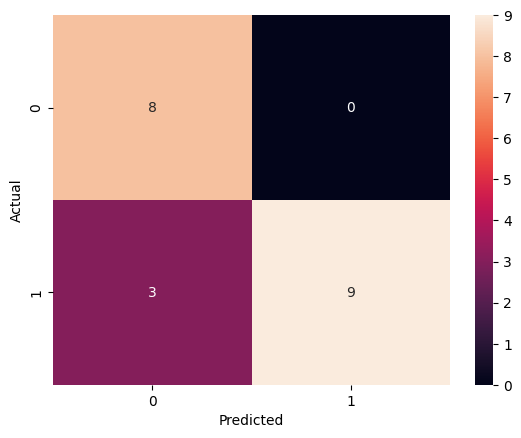

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
y_pred = model.predict(X_train)

print("Accuracy:", accuracy_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print("Recall:", recall_score(y_train, y_pred))
print("F1 Score:", f1_score(y_train, y_pred))

Accuracy: 0.9625
Precision: 0.972972972972973
Recall: 0.9473684210526315
F1 Score: 0.96


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 2 36]]


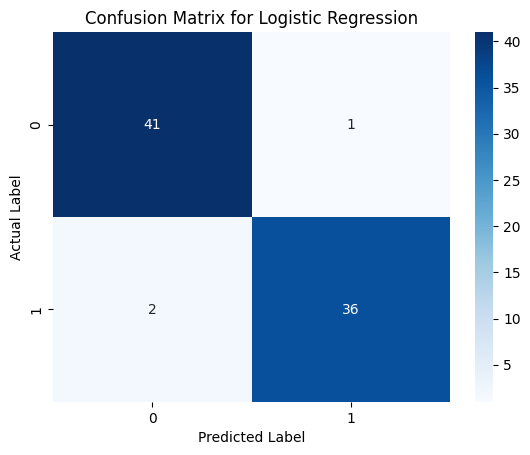

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Logistic Regression")

plt.show()